In [23]:
import numpy as np

In [24]:
from preprocessing import preprocess 
X_train, y_train, X_val, y_val, X_test, y_test, weights = preprocess(feature_method="pca", balance = False)


Loading MNIST dataset...
Split completed: Train=54000, Val=6000, Test=10000


In [25]:
class KNN:
    def __init__(self, weights='uniform', k=3, metric='euclidean'):
        self.k = k
        self.weights = weights
        self.metric = metric

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def _compute_distances(self, X):
        """Compute distances from all test points to all training points at once."""
        if self.metric == 'euclidean':
            a2 = np.sum(X ** 2, axis=1, keepdims=True)           # (n_test, 1)
            b2 = np.sum(self.X_train ** 2, axis=1, keepdims=True) # (n_train, 1)
            dists = np.sqrt(np.maximum(a2 + b2.T - 2 * X @ self.X_train.T, 0))

        elif self.metric == 'manhattan':
            # Loop over test points but vectorize(using numpy) over training points
            dists = np.array([
                np.sum(np.abs(self.X_train - x), axis=1) for x in X
            ])

        elif self.metric == 'cosine':
            X_norm = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-9)
            T_norm = self.X_train / (np.linalg.norm(self.X_train, axis=1, keepdims=True) + 1e-9)
            dists = 1 - X_norm @ T_norm.T

        else:
            raise ValueError(f"Metric '{self.metric}' not supported in vectorized mode")

        return dists 

    def predict(self, X):
        X = np.array(X)
        dists = self._compute_distances(X)          # (n_test, n_train)
        k_idx = np.argsort(dists, axis=1)[:, :self.k]  # (n_test, k)

        predictions = []
        for i, neighbors in enumerate(k_idx):
            labels = self.y_train[neighbors]
            if self.weights == 'uniform':
                weights = np.ones(self.k)
            else:
                weights = 1 / (dists[i, neighbors] + 1e-9)

            votes = {}
            for label, w in zip(labels, weights):
                votes[label] = votes.get(label, 0) + w
            predictions.append(max(votes, key=votes.get))

        return np.array(predictions)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

In [27]:
import matplotlib.pyplot as plt
import numpy as np

def plot_elbow_knn_manual(knn, X_val, y_val, k_range):
    errors = []

    for k in k_range:
        print(f"Running k = {k} ...")

        knn.k = k  # update k

        y_pred = knn.predict(X_val)

        acc = np.mean(y_pred == y_val)   # correct way
        error = 1 - acc

        errors.append(error)

        print(f"k={k}, Accuracy={acc:.4f}, Error={error:.4f}")

    # Plot
    plt.figure()
    plt.plot(k_range, errors, marker='o')
    plt.xlabel("k")
    plt.ylabel("Error")
    plt.title("Elbow Method (Manual KNN)")
    plt.show()

    return errors

In [ ]:
#create an instance of the KNN class
knn = KNN(weights='uniform', k=3, metric='euclidean') 
#fit the model to the training data
knn.fit(X_train, y_train) 



Running k = 1 ...
k=1, Accuracy=0.9987, Error=0.0013
Running k = 3 ...
k=3, Accuracy=0.9988, Error=0.0012
Running k = 5 ...
k=5, Accuracy=0.9987, Error=0.0013
Running k = 7 ...
k=7, Accuracy=0.9985, Error=0.0015
Running k = 9 ...
k=9, Accuracy=0.9987, Error=0.0013
Running k = 11 ...
k=11, Accuracy=0.9987, Error=0.0013
Running k = 13 ...
k=13, Accuracy=0.9987, Error=0.0013


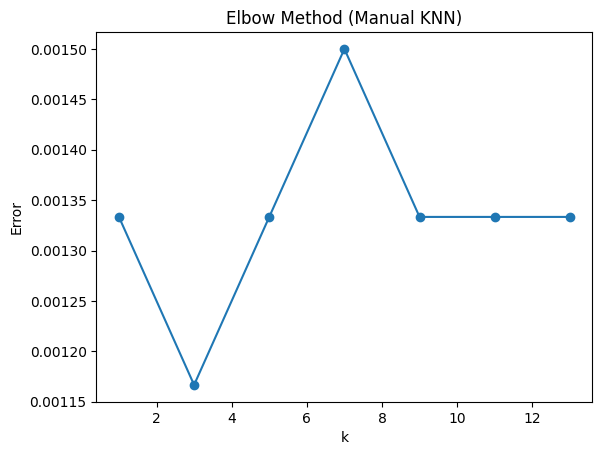

Done running elbow method for KNN.
Errors for KNN: [np.float64(0.0013333333333332975), np.float64(0.0011666666666666492), np.float64(0.0013333333333332975), np.float64(0.0014999999999999458), np.float64(0.0013333333333332975), np.float64(0.0013333333333332975), np.float64(0.0013333333333332975)]


In [28]:
# Run the elbow method
k_values = range(1, 15, 2)

errors = plot_elbow_knn_manual(knn, X_val, y_val, k_values)
print("Done running elbow method for KNN.")
print("Errors for KNN:", errors)

In [35]:
def evaluate(X, y, dataset_name="Validation"):
    y_pred = knn.predict(X)
    y_true = y

    # Positive class = 0 (digit zero)
    TP = np.sum((y_pred == 0) & (y_true == 0))
    TN = np.sum((y_pred == 1) & (y_true == 1))
    FP = np.sum((y_pred == 0) & (y_true == 1))
    FN = np.sum((y_pred == 1) & (y_true == 0))

    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    print(f"--- {dataset_name} Results ---")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")

    print("Confusion Matrix:")
    print(f"                 Predicted 0   Predicted 1")
    print(f"  Actual 0   :   {TP:<12}  {FN}")
    print(f"  Actual 1   :   {FP:<12}  {TN}")

In [36]:
evaluate(X_val, y_val, dataset_name="Validation FULL")

--- Validation FULL Results ---
Accuracy  : 0.9987
Precision : 0.9966
Recall    : 0.9898
F1-Score  : 0.9932
Confusion Matrix:
                 Predicted 0   Predicted 1
  Actual 0   :   581           6
  Actual 1   :   2             5411


In [37]:
evaluate(X_test, y_test, dataset_name="Test")

--- Test Results ---
Accuracy  : 0.9972
Precision : 0.9808
Recall    : 0.9908
F1-Score  : 0.9858
Confusion Matrix:
                 Predicted 0   Predicted 1
  Actual 0   :   971           9
  Actual 1   :   19            9001


In [32]:
 
from  preprocessing import custom_classification_report, custom_confusion_matrix
y_pred = knn.predict(X_val)
print(custom_classification_report(y_val, y_pred, target_names=["0 (Class 0)", "Not 0 (Class 1)"]))

# 2. Print the custom matrix
print(custom_confusion_matrix(y_val, y_pred, n_classes=2))

                 precision     recall   f1-score    support

0 (Class 0)           1.00       0.99       0.99        587
Not 0 (Class 1)       1.00       1.00       1.00       5413

accuracy                                    1.00       6000
macro avg             1.00       0.99       1.00       6000

[[ 581    6]
 [   2 5411]]


In [33]:
y_pred = knn.predict(X_test)
print(custom_classification_report(y_test, y_pred, target_names=["0 (Class 0)", "Not 0 (Class 1)"]))

# 2. Print the custom matrix
print(custom_confusion_matrix(y_test, y_pred, n_classes=2))

                 precision     recall   f1-score    support

0 (Class 0)           0.98       0.99       0.98        980
Not 0 (Class 1)       1.00       1.00       1.00       9020

accuracy                                    1.00      10000
macro avg             0.99       0.99       0.99      10000

[[ 971    9]
 [  21 8999]]
